In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

2. Cargar los datos

In [ ]:
ruta = "../data/raw/mercado_inmobiliario_bogota.csv"

df = pd.read_csv(ruta)

df["MES"] = pd.to_datetime(
    df["MES"],
    format="%m/%d/%Y %I:%M:%S %p"
)

serie = (
    df.set_index("MES")["UNIDADES_VENDIDAS_TOTAL"]
    .asfreq("MS")
)

serie.head()

MES
2004-06-01    2204
2004-07-01    2539
2004-08-01    2917
2004-09-01    3036
2004-10-01    3201
Freq: MS, Name: UNIDADES_VENDIDAS_TOTAL, dtype: int64

3. Separar train y test

In [ ]:
train = serie.loc[: "2017-12-01"]
test = serie.loc["2018-01-01":]

print("Train:", train.shape)
print("Test:", test.shape)

Train: (163,)
Test: (18,)


In [ ]:
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

2004-06-01 00:00:00 2017-12-01 00:00:00
2018-01-01 00:00:00 2019-06-01 00:00:00


4. Visualiza la separación

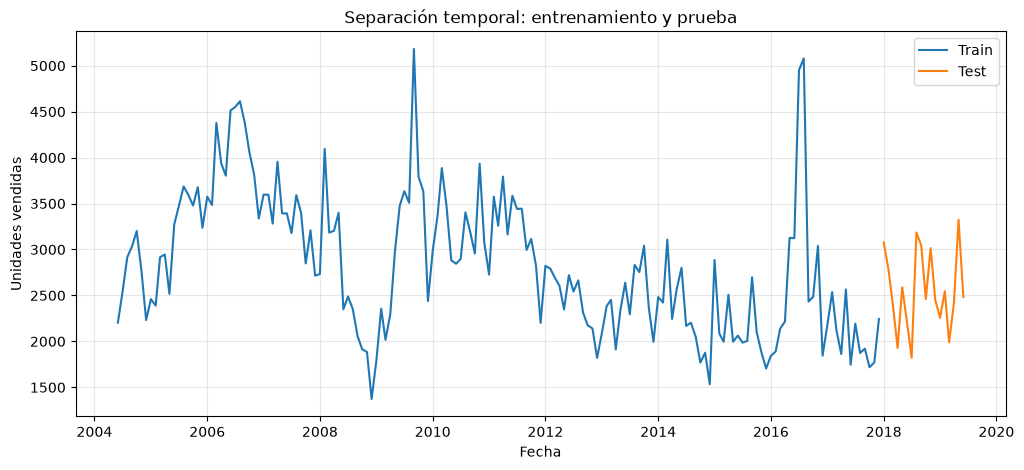

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")

plt.title("Separación temporal: entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Unidades vendidas")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Modelo 1: Naive estacional

In [ ]:
ultimos_12 = train.iloc[-12:].values

pred_naive = pd.Series(
    np.resize(ultimos_12, len(test)),
    index=test.index
)

pred_naive.head()

MES
2018-01-01    2179
2018-02-01    2536
2018-03-01    2120
2018-04-01    1862
2018-05-01    2565
Freq: MS, dtype: int64

In [ ]:
def evaluar_modelo(real, pred):
    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))

    mape = np.mean(
        np.abs((real - pred) / real)
    ) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [ ]:
metricas_naive = evaluar_modelo(test, pred_naive)
metricas_naive

{'MAE': 513.8888888888889,
 'RMSE': np.float64(661.6253555533608),
 'MAPE': np.float64(18.854525785026883)}

### Modelo 2: Holt-Winters

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

modelo_hw = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

ajuste_hw = modelo_hw.fit()

pred_hw = ajuste_hw.forecast(len(test))

pred_hw.head()

2018-01-01    2150.100874
2018-02-01    2366.262843
2018-03-01    2398.744955
2018-04-01    2365.427676
2018-05-01    2373.292976
Freq: MS, dtype: float64

In [ ]:
metricas_hw = evaluar_modelo(test, pred_hw)
metricas_hw

{'MAE': 395.0816219333091,
 'RMSE': np.float64(491.86851253092215),
 'MAPE': np.float64(15.404930958991104)}

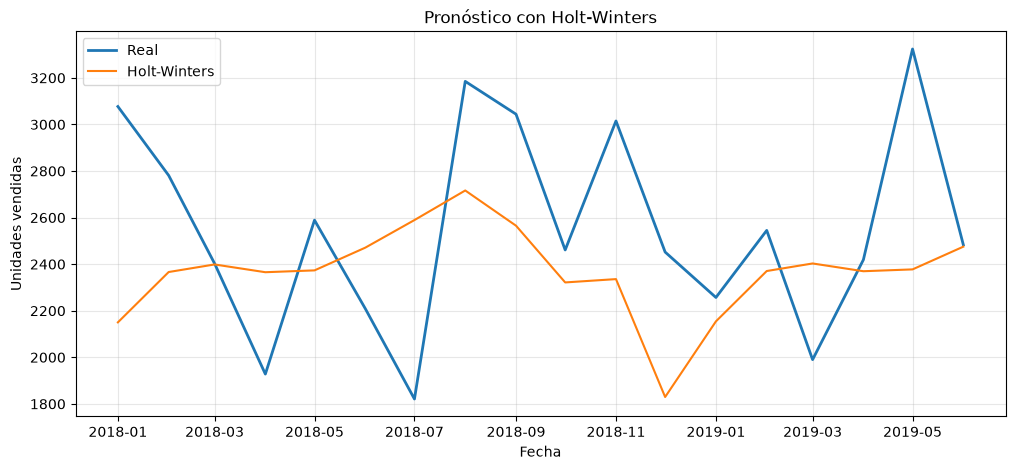

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Real", linewidth=2)
plt.plot(test.index, pred_hw, label="Holt-Winters")

plt.title("Pronóstico con Holt-Winters")
plt.xlabel("Fecha")
plt.ylabel("Unidades vendidas")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Modelo 3: SARIMA

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo_sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

ajuste_sarima = modelo_sarima.fit(disp=False)

pred_sarima = ajuste_sarima.forecast(steps=len(test))

pred_sarima.head()

2018-01-01    2170.537024
2018-02-01    2335.576866
2018-03-01    2416.304516
2018-04-01    2403.362615
2018-05-01    2330.408593
Freq: MS, Name: predicted_mean, dtype: float64

In [ ]:
metricas_sarima = evaluar_modelo(test, pred_sarima)
metricas_sarima

{'MAE': 402.92414162288946,
 'RMSE': np.float64(497.37728757339346),
 'MAPE': np.float64(15.836066017060041)}

### Comparación de modelos

Se compararon tres enfoques de pronóstico sobre un conjunto de prueba correspondiente a enero de 2018 - junio de 2019:

- Naive estacional
- Holt-Winters
- SARIMA

Holt-Winters obtuvo el mejor desempeño, con:

- MAE: 395.08 unidades
- RMSE: 491.87 unidades
- MAPE: 15.40 %

El modelo superó al baseline estacional y presentó un desempeño ligeramente mejor que SARIMA.

Esto sugiere que la combinación de tendencia y estacionalidad capturada por Holt-Winters es adecuada para representar la dinámica de la serie.

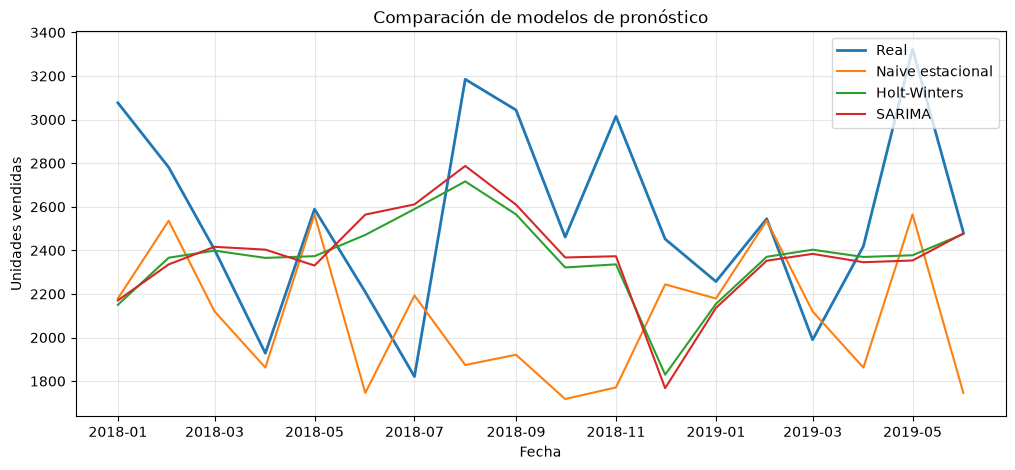

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Real", linewidth=2)
plt.plot(test.index, pred_naive, label="Naive estacional")
plt.plot(test.index, pred_hw, label="Holt-Winters")
plt.plot(test.index, pred_sarima, label="SARIMA")

plt.title("Comparación de modelos de pronóstico")
plt.xlabel("Fecha")
plt.ylabel("Unidades vendidas")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 1. Entrena Holt-Winters con toda la serie

In [ ]:
modelo_final = ExponentialSmoothing(
    serie,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

ajuste_final = modelo_final.fit()

2. Pronostica 12 meses

In [ ]:
forecast_12m = ajuste_final.forecast(12)

forecast_12m

2019-07-01    2778.344838
2019-08-01    2987.385241
2019-09-01    2840.180010
2019-10-01    2576.205386
2019-11-01    2619.461310
2019-12-01    2112.217592
2020-01-01    2465.899792
2020-02-01    2650.747732
2020-03-01    2620.851217
2020-04-01    2586.854769
2020-05-01    2700.261409
2020-06-01    2703.044512
Freq: MS, dtype: float64

3. Grafica histórico + pronóstico

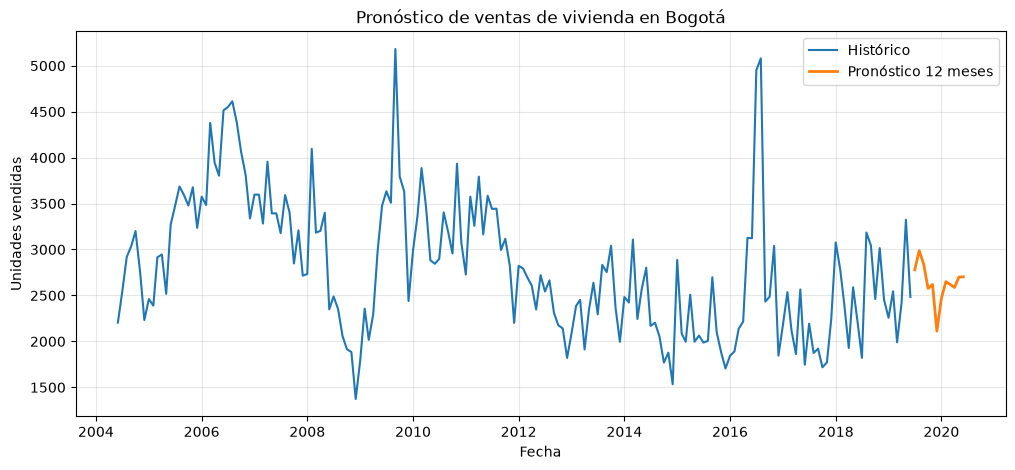

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(serie.index, serie, label="Histórico")
plt.plot(
    forecast_12m.index,
    forecast_12m,
    label="Pronóstico 12 meses",
    linewidth=2
)

plt.title("Pronóstico de ventas de vivienda en Bogotá")
plt.xlabel("Fecha")
plt.ylabel("Unidades vendidas")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

4. Guarda el pronóstico

In [ ]:
forecast_df = forecast_12m.reset_index()

forecast_df.columns = [
    "MES",
    "UNIDADES_VENDIDAS_PRONOSTICADAS"
]

forecast_df

,MES,UNIDADES_VENDIDAS_PRONOSTICADAS
0,2019-07-01,2778.344838
1,2019-08-01,2987.385241
2,2019-09-01,2840.180010
3,2019-10-01,2576.205386
4,2019-11-01,2619.461310
5,2019-12-01,2112.217592
6,2020-01-01,2465.899792
7,2020-02-01,2650.747732
8,2020-03-01,2620.851217
9,2020-04-01,2586.854769


In [ ]:
forecast_df.to_csv(
    "../data/processed/pronostico_12_meses.csv",
    index=False
)

5. Resumen del pronóstico

In [ ]:
print("Promedio mensual pronosticado:",
      round(forecast_12m.mean(), 0))

print("Máximo pronosticado:",
      round(forecast_12m.max(), 0),
      forecast_12m.idxmax())

print("Mínimo pronosticado:",
      round(forecast_12m.min(), 0),
      forecast_12m.idxmin())

Promedio mensual pronosticado: 2637.0
Máximo pronosticado: 2987.0 2019-08-01 00:00:00
Mínimo pronosticado: 2112.0 2019-12-01 00:00:00


In [ ]:
print(
    "Ventas pronosticadas en 12 meses:",
    round(forecast_12m.sum(), 0)
)

Ventas pronosticadas en 12 meses: 31641.0


#### 1. Guardar una tabla de comparación de modelos

In [ ]:
resultados = pd.DataFrame({
    "Naive estacional": metricas_naive,
    "Holt-Winters": metricas_hw,
    "SARIMA": metricas_sarima
}).T

resultados

,MAE,RMSE,MAPE
Naive estacional,513.888889,661.625356,18.854526
Holt-Winters,395.081622,491.868513,15.404931
SARIMA,402.924142,497.377288,15.836066


In [ ]:
resultados.to_csv(
    "../data/processed/comparacion_modelos.csv"
)

2. Exportar el dataset limpio

In [ ]:
df.to_csv(
    "../data/processed/mercado_inmobiliario_bogota_limpio.csv",
    index=False
)